In [1]:
import io
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. FILE UPLOAD & FALLBACK SYNTHETIC GENERATOR
# ==========================================
try:
    from google.colab import files
    print("Please upload your IPL CSV dataset:")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"Successfully loaded '{file_name}'!")
except Exception:
    print("No file uploaded or running locally. Generating synthetic IPL match dataset matching schema...")
    np.random.seed(42)
    n_rows = 500

    teams = ['Chennai Super Kings', 'Mumbai Indians', 'Royal Challengers Bengaluru',
             'Kolkata Knight Riders', 'Rajasthan Royals', 'Gujarat Titans', 'Delhi Capitals', 'Punjab Kings']
    cities = ['Mumbai', 'Chennai', 'Bengaluru', 'Kolkata', 'Jaipur', 'Ahmedabad', 'Delhi', 'Chandigarh']
    venues = [f"{c} Cricket Stadium" for c in cities]
    players = ['MS Dhoni', 'Virat Kohli', 'Rohit Sharma', 'Sunil Narine', 'Jos Buttler', 'Hardik Pandya', 'KL Rahul', 'Shubman Gill']

    rows = []
    for i in range(n_rows):
        t1, t2 = np.random.choice(teams, size=2, replace=False)
        toss_w = np.random.choice([t1, t2])
        toss_d = np.random.choice(['bat', 'field'])
        winner = np.random.choice([t1, t2], p=[0.52, 0.48])
        t1_runs = np.random.randint(120, 220)
        t2_runs = np.random.randint(110, 215)
        t1_wkts = np.random.randint(2, 10)
        t2_wkts = np.random.randint(3, 10)

        res_type = 'runs' if winner == t1 else 'wickets'
        by_runs = np.random.randint(1, 60) if res_type == 'runs' else 0
        by_wkts = np.random.randint(1, 9) if res_type == 'wickets' else 0

        rows.append({
            'event_name': 'Indian Premier League',
            'season': np.random.choice(['2021', '2022', '2023', '2024', '2025']),
            'match_number': i + 1,
            'date': pd.date_range(start='2021-04-01', periods=n_rows, freq='D')[i].strftime('%Y-%m-%d'),
            'city': np.random.choice(cities),
            'venue': np.random.choice(venues),
            'team1': t1,
            'team2': t2,
            'toss_winner': toss_w,
            'toss_decision': toss_d,
            'team1_runs': t1_runs,
            'team1_wickets': t1_wkts,
            'team2_runs': t2_runs,
            'team2_wickets': t2_wkts,
            'winner': winner,
            'result_type': res_type,
            'win_by_runs': by_runs,
            'win_by_wickets': by_wkts,
            'player_of_match': np.random.choice(players),
            'match_referee': 'Ref Admin',
            'umpire1': 'Umpire A',
            'umpire2': 'Umpire B',
            'tv_umpire': 'TV Umpire',
            'reserve_umpire': 'Res Umpire',
            'match_type': 'T20',
            'overs_limit': 20,
            'balls_per_over': 6,
            'gender': 'male',
            'team_type': 'club',
            'team1_players': 'Player List 1',
            'team2_players': 'Player List 2'
        })
    df = pd.DataFrame(rows)

# Clean column headers
df.columns = df.columns.str.strip()

# Datetime & numeric parsing
df['date'] = pd.to_datetime(df['date'], errors='coerce')
num_cols = ['team1_runs', 'team1_wickets', 'team2_runs', 'team2_wickets', 'win_by_runs', 'win_by_wickets', 'overs_limit']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Derived Sports Analytics Metrics
df['Total_Match_Runs'] = df['team1_runs'] + df['team2_runs']
df['Total_Match_Wickets'] = df['team1_wickets'] + df['team2_wickets']
df['Team1_Run_Rate'] = np.where(df['overs_limit'] > 0, df['team1_runs'] / df['overs_limit'], 0)
df['Team2_Run_Rate'] = np.where(df['overs_limit'] > 0, df['team2_runs'] / df['overs_limit'], 0)
df['Toss_Match_Win_Match'] = np.where(df['toss_winner'] == df['winner'], 'Toss Winner Won Match', 'Toss Winner Lost Match')

print(f"Dataset Successfully Preprocessed! Total Records: {len(df)} | Columns: {len(df.columns)}")
df[['date', 'season', 'team1', 'team2', 'winner', 'Total_Match_Runs', 'Toss_Match_Win_Match']].head(3)

Please upload your IPL CSV dataset:


Saving IPL_Matches_Data_2008_2026.csv to IPL_Matches_Data_2008_2026.csv
Successfully loaded 'IPL_Matches_Data_2008_2026.csv'!
Dataset Successfully Preprocessed! Total Records: 1243 | Columns: 36


/tmp/ipykernel_916/1591545235.py:84: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


,date,season,team1,team2,winner,Total_Match_Runs,Toss_Match_Win_Match
0,2008-04-18,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,304,Toss Winner Lost Match
1,2008-04-19,2007/08,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,447,Toss Winner Won Match
2,2008-04-19,2007/08,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,261,Toss Winner Lost Match


In [2]:
# Construct Source-Target mapping for Toss Decision -> Toss Outcome -> Match Winner
sankey_df = df.groupby(['toss_decision', 'Toss_Match_Win_Match', 'winner']).size().reset_index(name='Count')

labels = list(pd.unique(sankey_df[['toss_decision', 'Toss_Match_Win_Match', 'winner']].values.ravel('K')))
label_map = {lbl: i for i, lbl in enumerate(labels)}

sources, targets, values = [], [], []

for _, row in sankey_df.iterrows():
    sources.append(label_map[row['toss_decision']])
    targets.append(label_map[row['Toss_Match_Win_Match']])
    values.append(row['Count'])

    sources.append(label_map[row['Toss_Match_Win_Match']])
    targets.append(label_map[row['winner']])
    values.append(row['Count'])

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=labels, color="darkblue"),
    link=dict(source=sources, target=targets, value=values, color="rgba(31, 119, 180, 0.3)")
)])

fig_sankey.update_layout(title_text="Toss Decision Impact Flow: Choice → Toss Advantage → Match Winner", height=550)
fig_sankey.show()

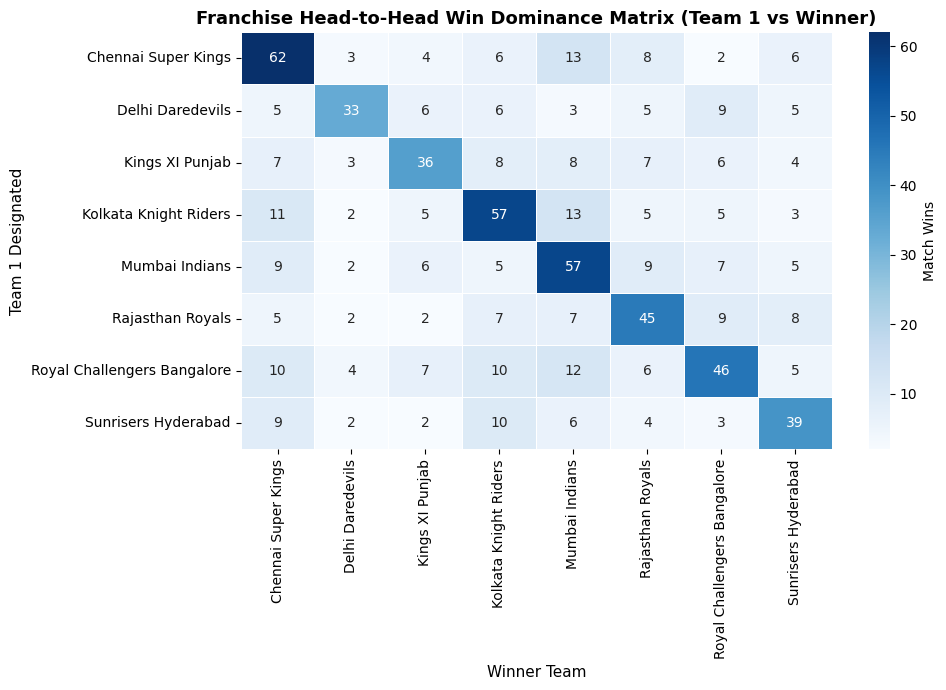

In [3]:
# Compute pairwise wins matrix between top franchises
top_teams = df['winner'].value_counts().nlargest(8).index
df_h2h = df[(df['team1'].isin(top_teams)) & (df['team2'].isin(top_teams))]

h2h_matrix = pd.crosstab(df_h2h['team1'], df_h2h['winner'])

plt.figure(figsize=(10, 7))
sns.heatmap(h2h_matrix, annot=True, cmap='Blues', fmt='d', linewidths=0.5, cbar_kws={'label': 'Match Wins'})
plt.title('Franchise Head-to-Head Win Dominance Matrix (Team 1 vs Winner)', fontsize=13, fontweight='bold')
plt.xlabel('Winner Team', fontsize=11)
plt.ylabel('Team 1 Designated', fontsize=11)
plt.tight_layout()
plt.show()

In [4]:
fig_scoring = px.scatter(
    df,
    x='team1_runs',
    y='team2_runs',
    size='Total_Match_Runs',
    color='winner',
    hover_data=['season', 'venue', 'win_by_runs', 'win_by_wickets'],
    title="Match Run Production & Target Pursuit Dynamics (Team 1 Runs vs Team 2 Runs)",
    labels={'team1_runs': 'Team 1 Innings Score', 'team2_runs': 'Team 2 Innings Score'}
)

# Reference parity line (Equal scores)
fig_scoring.add_shape(
    type="line", line=dict(dash="dash", color="gray"),
    x0=100, y0=100, x1=230, y1=230
)

fig_scoring.update_layout(height=550)
fig_scoring.show()

In [7]:
# Drop rows with missing values in path columns
df_sunburst = df.dropna(subset=['winner', 'player_of_match']).copy()

# Filter out empty or 'nan' string values
df_sunburst = df_sunburst[
    (df_sunburst['winner'].astype(str).str.lower() != 'nan') &
    (df_sunburst['player_of_match'].astype(str).str.lower() != 'nan')
]

fig_sunburst = px.sunburst(
    df_sunburst,
    path=['winner', 'player_of_match'],
    values='Total_Match_Runs',
    color='winner',
    title="Match Impact Hierarchy: Franchise Victories → Top Match Performers (Player of the Match)"
)
fig_sunburst.update_layout(height=600)
fig_sunburst.show()

In [8]:
fig_season = px.box(
    df,
    x='season',
    y='Total_Match_Runs',
    color='season',
    points='all',
    title="Longitudinal Season Scoring Trajectory & Total Match Run Volatility",
    labels={'season': 'IPL Season', 'Total_Match_Runs': 'Combined Match Score'}
)
fig_season.update_layout(height=500)
fig_season.show()

In [9]:
# Filter top 10 venues by total match count
top_venues = df['venue'].value_counts().nlargest(10).index
df_venue = df[df['venue'].isin(top_venues)].dropna(subset=['win_by_runs', 'win_by_wickets']).copy()

# Classify match outcome as Defending or Chasing
df_venue['Win_Method'] = np.where(
    df_venue['win_by_runs'] > 0, 'Defending (Bat 1st)',
    np.where(df_venue['win_by_wickets'] > 0, 'Chasing (Bat 2nd)', 'Tie/No Result')
)
df_venue_clean = df_venue[df_venue['Win_Method'] != 'Tie/No Result']

fig_venue = px.histogram(
    df_venue_clean,
    y='venue',
    color='Win_Method',
    barmode='stack',
    color_discrete_map={'Defending (Bat 1st)': '#d62728', 'Chasing (Bat 2nd)': '#2ca02c'},
    title="Venue Pitch Bias: Defending (Bat 1st) vs. Chasing (Bat 2nd) Victories Across Top 10 Venues",
    labels={'venue': 'Venue / Stadium', 'count': 'Match Count'}
)
fig_venue.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig_venue.show()

In [10]:
# Filter top 8 franchises
top_8_teams = df['toss_winner'].value_counts().nlargest(8).index
df_toss = df[df['toss_winner'].isin(top_8_teams)].dropna(subset=['toss_winner', 'toss_decision', 'winner']).copy()

# Map toss-to-match win conversion
df_toss['Toss_Outcome'] = np.where(
    df_toss['toss_winner'] == df_toss['winner'],
    'Toss Won & Match Won',
    'Toss Won & Match Lost'
)

toss_summary = df_toss.groupby(['toss_winner', 'toss_decision', 'Toss_Outcome']).size().reset_index(name='Count')

fig_toss_strat = px.bar(
    toss_summary,
    x='toss_winner',
    y='Count',
    color='Toss_Outcome',
    facet_col='toss_decision',
    barmode='group',
    color_discrete_map={'Toss Won & Match Won': '#1f77b4', 'Toss Won & Match Lost': '#ff7f0e'},
    title="Franchise Toss Strategy & Conversion: Decision Impact (Bat vs. Field) on Match Outcome",
    labels={'toss_winner': 'Franchise', 'Count': 'Matches', 'toss_decision': 'Decision'}
)
fig_toss_strat.update_layout(height=500)
fig_toss_strat.show()

In [11]:
# ==========================================
# CELL 9: PARALLEL CATEGORIES MATCH CONTEXT FLOW
# ==========================================
import plotly.express as px

# Filter top 6 franchises and clean context columns
top_6_teams = df['winner'].value_counts().nlargest(6).index
df_parcat = df[df['winner'].isin(top_6_teams)].dropna(subset=['city', 'toss_decision', 'result_type', 'winner']).copy()

fig_parcat = px.parallel_categories(
    df_parcat,
    dimensions=['city', 'toss_decision', 'result_type', 'winner'],
    color='Total_Match_Runs',
    color_continuous_scale='Viridis',
    title="Match Context Funnel: Host City → Toss Choice → Victory Type → Winner",
    labels={
        'city': 'Host City',
        'toss_decision': 'Toss Choice',
        'result_type': 'Victory Type',
        'winner': 'Match Winner'
    }
)
fig_parcat.update_layout(height=550)
fig_parcat.show()

In [12]:
# ==========================================
# CELL 10: FRANCHISE MULTI-METRIC PERFORMANCE RADAR
# ==========================================
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

# Calculate total matches played per team
matches_played = (df['team1'].value_counts().add(df['team2'].value_counts(), fill_value=0))

# Aggregate franchise performance metrics
wins = df['winner'].value_counts()
toss_wins = df['toss_winner'].value_counts()
potm_count = df['player_of_match'].value_counts()

# Compute average runs scored per team across both innings
team1_runs_avg = df.groupby('team1')['team1_runs'].mean()
team2_runs_avg = df.groupby('team2')['team2_runs'].mean()
avg_runs = (team1_runs_avg.add(team2_runs_avg, fill_value=0) / 2)

top_teams_radar = wins.nlargest(5).index

# Construct normalized benchmarking DataFrame
radar_data = pd.DataFrame({
    'Win_Rate': (wins / matches_played * 100).fillna(0),
    'Toss_Win_Rate': (toss_wins / matches_played * 100).fillna(0),
    'Avg_Runs': avg_runs,
    'POTM_Impact': potm_count
}).loc[top_teams_radar].fillna(0)

scaler = MinMaxScaler(feature_range=(10, 100))
scaled_radar = pd.DataFrame(
    scaler.fit_transform(radar_data),
    columns=['Win Rate %', 'Toss Win Rate %', 'Avg Scoring Output', 'Star Performers (POTM)'],
    index=radar_data.index
)

categories = list(scaled_radar.columns)
fig_radar = go.Figure()

for team in scaled_radar.index:
    fig_radar.add_trace(go.Scatterpolar(
        r=scaled_radar.loc[team].values,
        theta=categories,
        fill='toself',
        name=team
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title="Multi-Dimensional Franchise Performance & Impact Radar Benchmarking",
    height=550
)
fig_radar.show()

In [13]:
# ==========================================
# CELL 11: FRANCHISE DYNASTY CUMULATIVE VICTORY PROGRESSION
# ==========================================
import plotly.express as px

# Filter top 6 franchises and aggregate seasonal victories
top_6_teams = df['winner'].value_counts().nlargest(6).index
df_season_wins = df[df['winner'].isin(top_6_teams)].dropna(subset=['winner', 'season']).copy()

season_wins = df_season_wins.groupby(['season', 'winner']).size().reset_index(name='Season_Wins')

# Sort and calculate cumulative win trajectory across seasons
season_wins = season_wins.sort_values('season')
season_wins['Cumulative_Wins'] = season_wins.groupby('winner')['Season_Wins'].cumsum()

fig_dynasty = px.line(
    season_wins,
    x='season',
    y='Cumulative_Wins',
    color='winner',
    markers=True,
    title="Franchise Dynasty Trajectory: Cumulative Victory Progression Across Seasons",
    labels={'season': 'IPL Season', 'Cumulative_Wins': 'Cumulative Wins', 'winner': 'Franchise'}
)
fig_dynasty.update_layout(height=500)
fig_dynasty.show()

In [14]:
# ==========================================
# CELL 12: PITCH PROFILE CLASSIFIER (2D DENSITY CONTOUR)
# ==========================================
import plotly.express as px

# Filter top 6 high-frequency venues
top_venues = df['venue'].value_counts().nlargest(6).index
df_pitch = df[df['venue'].isin(top_venues)].dropna(subset=['Total_Match_Runs', 'Total_Match_Wickets']).copy()

fig_contour = px.density_contour(
    df_pitch,
    x='Total_Match_Runs',
    y='Total_Match_Wickets',
    color='venue',
    marginal_x='histogram',
    marginal_y='rug',
    title="Pitch Condition Matrix: 2D Density Contour (Match Scoring Output vs. Wicket Fall Rate)",
    labels={'Total_Match_Runs': 'Combined Match Score (Runs)', 'Total_Match_Wickets': 'Total Wickets Lost'}
)
fig_contour.update_layout(height=550)
fig_contour.show()

In [15]:
# ==========================================
# CELL 13: FRANCHISE DEFENSIVE DOMINANCE (WINNING MARGIN VIOLIN PLOT)
# ==========================================
import plotly.express as px

# Filter top 6 winning franchises for matches won when defending (win by runs > 0)
top_6_winners = df['winner'].value_counts().nlargest(6).index
df_defend = df[(df['winner'].isin(top_6_winners)) & (df['win_by_runs'] > 0)].copy()

fig_violin = px.violin(
    df_defend,
    x='winner',
    y='win_by_runs',
    color='winner',
    box=True,
    points='all',
    title="Franchise Defending Dominance: Distribution & Volatility of Run Win Margins",
    labels={'winner': 'Franchise', 'win_by_runs': 'Winning Margin (Runs)'}
)
fig_violin.update_layout(height=500, showlegend=False)
fig_violin.show()

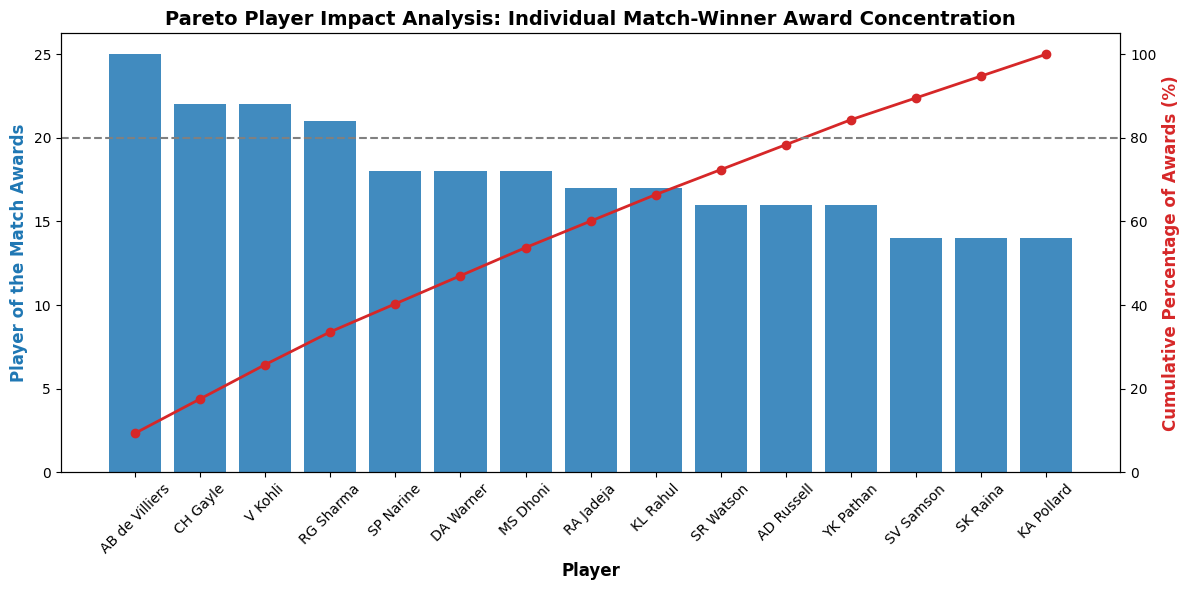

In [16]:
# ==========================================
# CELL 14: PARETO PLAYER OF THE MATCH (POTM) CONCENTRATION
# ==========================================
import matplotlib.pyplot as plt

# Aggregate top 15 Player of the Match award winners
potm_df = df['player_of_match'].value_counts().reset_index()
potm_df.columns = ['Player', 'Awards']
potm_df = potm_df.dropna().head(15)

# Calculate cumulative impact percentage
potm_df['Cumulative_Awards'] = potm_df['Awards'].cumsum()
potm_df['Cumulative_Perc'] = (potm_df['Cumulative_Awards'] / potm_df['Awards'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Absolute player award counts
ax1.bar(potm_df['Player'], potm_df['Awards'], color='#1f77b4', alpha=0.85)
ax1.set_ylabel('Player of the Match Awards', color='#1f77b4', fontsize=12, fontweight='bold')
ax1.set_xlabel('Player', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Secondary Axis: Cumulative percentage line
ax2 = ax1.twinx()
ax2.plot(potm_df['Player'], potm_df['Cumulative_Perc'], color='#d62728', marker='o', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, label='80% Cutoff')
ax2.set_ylabel('Cumulative Percentage of Awards (%)', color='#d62728', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105)

plt.title('Pareto Player Impact Analysis: Individual Match-Winner Award Concentration', fontsize=14, fontweight='bold')
plt.grid(visible=False)
plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# CELL 15: DUMBBELL PLOT (1st Innings vs 2nd Innings Average Score Gap by Venue)
# ==========================================
import plotly.graph_objects as go

# Filter top 10 venues by match frequency
top_10_venues = df['venue'].value_counts().nlargest(10).index
venue_scores = df[df['venue'].isin(top_10_venues)].groupby('venue').agg(
    Avg_Innings1=('team1_runs', 'mean'),
    Avg_Innings2=('team2_runs', 'mean')
).reset_index()

# Sort by 1st Innings average for clear layout hierarchy
venue_scores = venue_scores.sort_values(by='Avg_Innings1', ascending=True)

fig_dumbbell = go.Figure()

# Add connecting horizontal gap lines
for _, row in venue_scores.iterrows():
    fig_dumbbell.add_trace(go.Scatter(
        x=[row['Avg_Innings1'], row['Avg_Innings2']],
        y=[row['venue'], row['venue']],
        mode='lines',
        line=dict(color='#a0a0a0', width=2),
        showlegend=False
    ))

# Add 1st Innings Average markers (Blue)
fig_dumbbell.add_trace(go.Scatter(
    x=venue_scores['Avg_Innings1'],
    y=venue_scores['venue'],
    mode='markers',
    name='1st Innings Avg Runs',
    marker=dict(color='#1f77b4', size=11)
))

# Add 2nd Innings Average markers (Red)
fig_dumbbell.add_trace(go.Scatter(
    x=venue_scores['Avg_Innings2'],
    y=venue_scores['venue'],
    mode='markers',
    name='2nd Innings Avg Runs',
    marker=dict(color='#d62728', size=11)
))

fig_dumbbell.update_layout(
    title='Dumbbell Plot: Scoring Differential Between 1st and 2nd Innings Across Top Venues',
    xaxis=dict(title='Average Runs Scored'),
    yaxis=dict(title='Venue'),
    height=550
)
fig_dumbbell.show()

In [18]:
# ==========================================
# CELL 16: PARALLEL COORDINATES MULTI-METRIC MATCH PROFILE
# ==========================================
import plotly.express as px

# Prepare match metrics dataset
df_parallel = df.dropna(subset=['team1_runs', 'team1_wickets', 'team2_runs', 'team2_wickets', 'Total_Match_Runs']).copy()

fig_parallel = px.parallel_coordinates(
    df_parallel,
    dimensions=['team1_runs', 'team1_wickets', 'team2_runs', 'team2_wickets', 'Total_Match_Runs'],
    color='Total_Match_Runs',
    color_continuous_scale='Plasma',
    title="Multi-Dimensional Match Dynamics Profile (Parallel Coordinates)",
    labels={
        'team1_runs': 'Team 1 Runs',
        'team1_wickets': 'Team 1 Wickets',
        'team2_runs': 'Team 2 Runs',
        'team2_wickets': 'Team 2 Wickets',
        'Total_Match_Runs': 'Total Score'
    }
)
fig_parallel.update_layout(height=550)
fig_parallel.show()